# Automatic Evaluation 

### Init

In [1]:
import pandas as pd 
import numpy as np
import pickle
import os 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

In [2]:
# From variables 
# criteria = ["Completeness", "Step-by-step concordance", "Case-tailoring concordance", "Missing data concordance"]
# criteria = ["Completeness", "Step_concordance", "Case_tailoring", "Missing_data_concordance"]
criteria = ["Completeness", "Step_concordance", "Missing_data_concordance"]

approaches = ["Model_Alone", "Model_Studies", "Model_Workflow", "Model_Workflow_Studies"]
approaches_names_map = {"Model_Alone":"LLM-baseline", "Model_Studies":"RAG-LLM", "Model_Workflow":"WF-LLM", "Model_Workflow_Studies":"WF-RAG-LLM"}

# step2_labels = ["Cancer_Surgery", "Imaging_Test", "Therapy"]
# step3_labels = ["Biomarker","Biomarker_Result", "Cancer_Surgery", "Grade","Histological_Type","Imaging_Test","Invasion", "Metastasis", "Oncogene", "Response_To_Treatment",
#           "Staging","Therapy","Tumor_Finding","Tumor_Size"]

In [3]:
n_case_eval = 100

### LLM-as-a-Jury (recommendation iteration procedure)

In [5]:
# Read data and build one dataset 
model_brief_names = ["claude", "gpt", "llama"]
model_names = {"claude":"Claude Sonnet 4.6", "gpt":"GPT-4o", "llama":"Llama 3.3 70B"}
min_max_values = {m:[] for m in model_brief_names}

strategy = "OneText_OnePrompt"
version = "v5"
iteration = ["iteration_0","iteration_1","iteration_2"] # multiple recomendation iterations 
model_dirs = {m:[f"results_{m}_{strategy}/{version}_{i}" for i in iteration] for m in model_brief_names}
runs = [0] # consider only the first run

# res path 
res_dir = f"results/{version}_overall_results_recommendation_iteration_eval_run_0"

In [6]:
eval_final_data = pd.DataFrame(columns=["Approach","Judge","Iteration","Criterion","Acc_Satisfied"])
for m in model_dirs.keys():
    for d in model_dirs[m]:
        m_files = os.listdir(d)
        for it in iteration:
            if it in d:
                iteration_num = it.split("_")[-1]
        for r in runs:
            for a in approaches: 
                f_name = f"{d}/eval_{a}_run_{r}.csv"
                f_content = pd.read_csv(f_name)
                for c in criteria:
                    c_col = f_content.loc[:,c].values
                    acc_= round(np.mean(c_col),3)
                    eval_final_data.loc[len(eval_final_data)] = [a, m, iteration_num, c, acc_]

In [8]:
# Normalization per model (judge)
new_columns=["Approach","Judge","Iteration","Criterion","Normalized_Acc_Satisfied"]
eval_final_data_normalized = pd.DataFrame(columns=new_columns)
for m in model_brief_names:
    data_normalized = eval_final_data.loc[eval_final_data["Judge"]==m, "Approach":"Criterion"]
    m_r_data = eval_final_data.loc[eval_final_data["Judge"]==m, "Acc_Satisfied"].values
    min_max_values[m] = [np.min(m_r_data), np.max(m_r_data)]
    print(f"Model judge: {m} --> len: {len(m_r_data)}; min_max: {min_max_values[m]}")
    normalized_values = (m_r_data - min_max_values[m][0])/(min_max_values[m][1]-min_max_values[m][0])
    round_values = [round(n,3) for n in normalized_values]
    data_normalized.insert(len(data_normalized.columns), "Normalized_Acc_Satisfied", round_values)

    eval_final_data_normalized = pd.concat([eval_final_data_normalized, data_normalized])

Model judge: claude --> len: 36; min_max: [np.float64(0.49), np.float64(0.97)]
Model judge: gpt --> len: 36; min_max: [np.float64(0.1), np.float64(0.59)]
Model judge: llama --> len: 36; min_max: [np.float64(0.13), np.float64(0.8)]


In [12]:
summary_eval_tb = pd.DataFrame(columns=["Judge", "Criterion", "Approach", "Mean_Accuracy_Across_Iteration"])
summary_eval_tb_for_graph = pd.DataFrame(columns=["Judge", "Criterion", "Approach", "Mean_Accuracy_Across_Iteration", "STD_Accuracy_Across_Iteration"])
for m in model_brief_names:
    for c in criteria:
        for a in approaches:
            data_a_m_c = eval_final_data_normalized.loc[(eval_final_data_normalized["Approach"]==a) & (eval_final_data_normalized["Judge"]==m) & (eval_final_data_normalized["Criterion"]==c),"Normalized_Acc_Satisfied"].values
            print(f"Approach {a}, Judge: {m}, Criterion: {c}: {len(data_a_m_c)}")
            summary_mean = round(np.mean(data_a_m_c),3)
            summary_std = round(np.std(data_a_m_c),3)
            summary_eval_tb.loc[len(summary_eval_tb)] = [model_names[m], c, approaches_names_map[a], f"{summary_mean} ({summary_std})"]
            summary_eval_tb_for_graph.loc[len(summary_eval_tb_for_graph)] = [model_names[m], c, approaches_names_map[a], summary_mean, summary_std]

Approach Model_Alone, Judge: claude, Criterion: Completeness: 3
Approach Model_Studies, Judge: claude, Criterion: Completeness: 3
Approach Model_Workflow, Judge: claude, Criterion: Completeness: 3
Approach Model_Workflow_Studies, Judge: claude, Criterion: Completeness: 3
Approach Model_Alone, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Studies, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Workflow, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Workflow_Studies, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Alone, Judge: claude, Criterion: Missing_data_concordance: 3
Approach Model_Studies, Judge: claude, Criterion: Missing_data_concordance: 3
Approach Model_Workflow, Judge: claude, Criterion: Missing_data_concordance: 3
Approach Model_Workflow_Studies, Judge: claude, Criterion: Missing_data_concordance: 3
Approach Model_Alone, Judge: gpt, Criterion: Completeness: 3
Approach Model_Studies, Judge: gpt, Criterion: Completeness

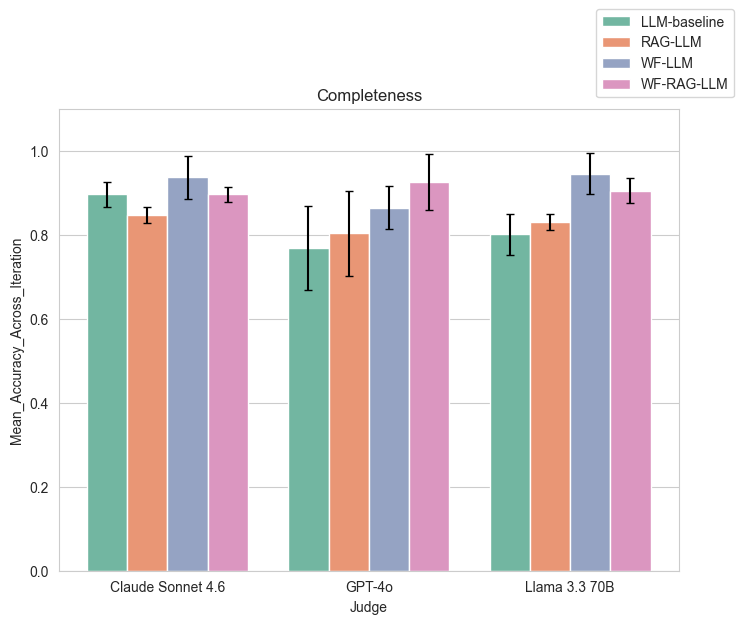

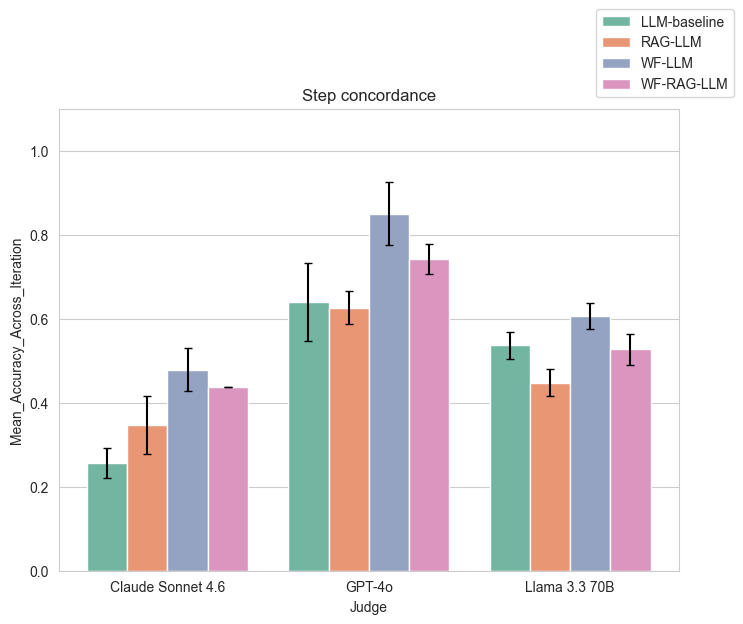

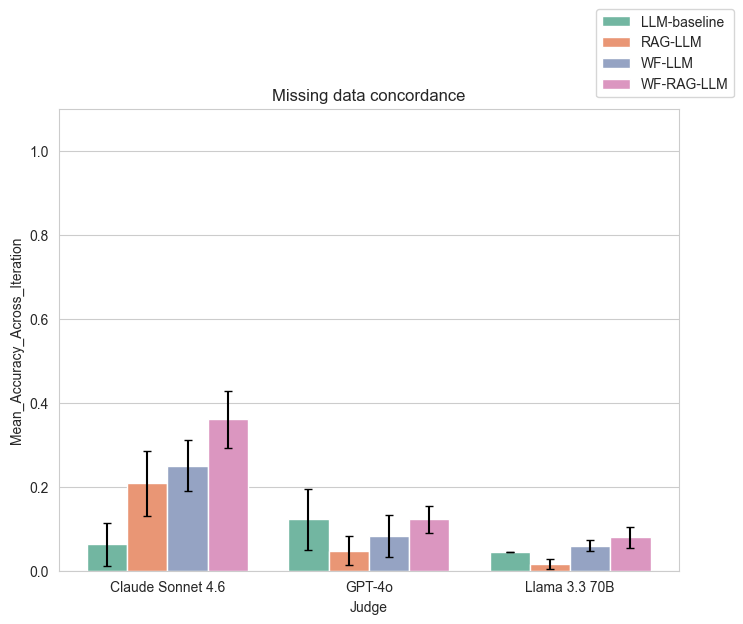

In [ ]:
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for c in criteria:
    data_plot = summary_eval_tb_for_graph.loc[summary_eval_tb_for_graph["Criterion"]==c]
    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Judge", y="Mean_Accuracy_Across_Iteration", hue="Approach", errorbar=None)

    x_positions = {
        cat: i for i, cat in enumerate(data_plot["Judge"].unique())
    }

    n_hue = data_plot["Approach"].nunique()
    width = 0.8 / n_hue

    for i, (_, row) in enumerate(data_plot.iterrows()):
        x = x_positions[row["Judge"]]
        
        hue_index = list(data_plot["Approach"].unique()).index(row["Approach"])
        offset = -0.4 + width/2 + hue_index * width
        
        ax.errorbar(
            x=x + offset,
            y=row["Mean_Accuracy_Across_Iteration"],
            yerr=row["STD_Accuracy_Across_Iteration"],
            fmt="none",
            color="black",
            capsize=3
        )
    plt.title(c.replace("_"," "))
    plt.ylim([0,1.1])
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.23))
    # ax.set_xticklabels(list(approaches_names_map.values()))
    plt.show()
    fig.savefig(f"{res_dir}/LLM_as_jury_{c}.png", dpi=600, format="png", bbox_inches='tight')

In [ ]:
eval_final_data.to_csv(f"{res_dir}/eval_final_data.csv", index=False)
eval_final_data_normalized.to_csv(f"{res_dir}/eval_final_data_normalized.csv", index=False)
summary_eval_tb.to_csv(f"{res_dir}/LLM_as_jury_results_{n_case_eval}_cases.csv", index=False)

### LLM-as-a-Jury (evaluation iteration procedure)

In [19]:
# Read data and build one dataset 
model_brief_names = ["claude", "gpt", "llama"]
model_names = {"claude":"Claude Sonnet 4.6", "gpt":"GPT-4o", "llama":"Llama 3.3 70B"}
min_max_values = {m:[] for m in model_brief_names}

strategy = "OneText_OnePrompt"
version = "v5"
iteration = "iteration_2"
model_dirs = [f"results_{m}_{strategy}/{version}_{iteration}" for m in model_brief_names]
runs = [0, 1, 2]

In [20]:
eval_final_data = pd.DataFrame(columns=["Approach","Judge","Iteration","Criterion","Sum_Satisfied","Mean_Satisfied","STD_Satisfied"])
for d in model_dirs:
    print(d)
    for m in model_brief_names:
        if m in d:
            model = m
    m_files = os.listdir(d)
    for r in runs:
        print("run ", r)
        for a in approaches: 
            # if r == 0:
            #     f_name = f"{d}/eval_{a}_first_snapshot.csv"
            # else:
            f_name = f"{d}/eval_{a}_run_{r}.csv"
            f_content = pd.read_csv(f_name)
            for c in criteria:
                c_col = f_content.loc[:,c].values
                # Stats across cases 
                s = np.sum(c_col)
                mean_= round(np.mean(c_col),3)
                std_ = round(np.std(c_col),3)
                eval_final_data.loc[len(eval_final_data)] = [a, model, r, c, s, mean_, std_]

results_claude_OneText_OnePrompt/v5_iteration_2
run  0
run  1
run  2
results_gpt_OneText_OnePrompt/v5_iteration_2
run  0
run  1
run  2
results_llama_OneText_OnePrompt/v5_iteration_2
run  0
run  1
run  2


In [ ]:
eval_final_data

In [21]:
# Normalization per model (judge)
new_columns=["Approach","Judge","Iteration","Criterion","Normalized_Mean_Satisfied"]
eval_final_data_normalized = pd.DataFrame(columns=new_columns)
for m in model_brief_names:
    data_normalized = eval_final_data.loc[eval_final_data["Judge"]==m, "Approach":"Criterion"]
    m_r_data = eval_final_data.loc[eval_final_data["Judge"]==m, "Mean_Satisfied"].values
    min_max_values[m] = [np.min(m_r_data), np.max(m_r_data)]
    print(f"Model judge: {m} --> len: {len(m_r_data)}; min_max: {min_max_values[m]}")
    normalized_values = (m_r_data - min_max_values[m][0])/(min_max_values[m][1]-min_max_values[m][0])
    round_values = [round(n,3) for n in normalized_values]
    data_normalized.insert(len(data_normalized.columns), "Normalized_Mean_Satisfied", round_values)

    eval_final_data_normalized = pd.concat([eval_final_data_normalized, data_normalized])

Model judge: claude --> len: 48; min_max: [np.float64(0.55), np.float64(0.95)]
Model judge: gpt --> len: 48; min_max: [np.float64(0.08), np.float64(0.58)]
Model judge: llama --> len: 48; min_max: [np.float64(0.048), np.float64(0.81)]


In [ ]:
eval_final_data_normalized

In [22]:
summary_eval_tb = pd.DataFrame(columns=["Judge", "Criterion", "Approach", "Mean_Satisfied_Across_Iteration"])
summary_eval_tb_for_graph = pd.DataFrame(columns=["Judge", "Criterion", "Approach", "Mean_Satisfied_Across_Iteration", "STD_Satisfied_Across_Iteration"])
for m in model_brief_names:
    for c in criteria:
        for a in approaches:
            data_a_m_c = eval_final_data_normalized.loc[(eval_final_data_normalized["Approach"]==a) & (eval_final_data_normalized["Judge"]==m) & (eval_final_data_normalized["Criterion"]==c),"Normalized_Mean_Satisfied"].values
            print(f"Approach {a}, Judge: {m}, Criterion: {c}: {len(data_a_m_c)}")
            summary_mean = round(np.mean(data_a_m_c),3)
            summary_std = round(np.std(data_a_m_c),3)
            summary_eval_tb.loc[len(summary_eval_tb)] = [model_names[m], c, approaches_names_map[a], f"{summary_mean} ({summary_std})"]
            summary_eval_tb_for_graph.loc[len(summary_eval_tb_for_graph)] = [model_names[m], c, approaches_names_map[a], summary_mean, summary_std]

Approach Model_Alone, Judge: claude, Criterion: Completeness: 3
Approach Model_Studies, Judge: claude, Criterion: Completeness: 3
Approach Model_Workflow, Judge: claude, Criterion: Completeness: 3
Approach Model_Workflow_Studies, Judge: claude, Criterion: Completeness: 3
Approach Model_Alone, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Studies, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Workflow, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Workflow_Studies, Judge: claude, Criterion: Step_concordance: 3
Approach Model_Alone, Judge: claude, Criterion: Case_tailoring: 3
Approach Model_Studies, Judge: claude, Criterion: Case_tailoring: 3
Approach Model_Workflow, Judge: claude, Criterion: Case_tailoring: 3
Approach Model_Workflow_Studies, Judge: claude, Criterion: Case_tailoring: 3
Approach Model_Alone, Judge: claude, Criterion: Missing_data_concordance: 3
Approach Model_Studies, Judge: claude, Criterion: Missing_data_concordance: 3
Approa

In [17]:
summary_eval_tb

,Judge,Criterion,Approach,Mean_Satisfied_Across_Iteration
0,Claude Sonnet 4.6,Completeness,LLM-baseline,0.978 (0.0)
1,Claude Sonnet 4.6,Completeness,RAG-LLM,0.941 (0.038)
2,Claude Sonnet 4.6,Completeness,WF-LLM,0.948 (0.021)
3,Claude Sonnet 4.6,Completeness,WF-RAG-LLM,0.993 (0.01)
4,Claude Sonnet 4.6,Step_concordance,LLM-baseline,0.215 (0.01)
5,Claude Sonnet 4.6,Step_concordance,RAG-LLM,0.304 (0.021)
6,Claude Sonnet 4.6,Step_concordance,WF-LLM,0.511 (0.0)
7,Claude Sonnet 4.6,Step_concordance,WF-RAG-LLM,0.459 (0.011)
8,Claude Sonnet 4.6,Case_tailoring,LLM-baseline,0.356 (0.018)
9,Claude Sonnet 4.6,Case_tailoring,RAG-LLM,0.629 (0.021)


In [23]:
summary_eval_tb.to_csv(f"results/{version}_{iteration}/LLM_as_jury_results_{n_case_eval}_cases.csv",index=False)
eval_final_data.to_csv(f"results/{version}_{iteration}/LLM_as_jury_complete_results_{n_case_eval}_cases.csv",index=False)
eval_final_data_normalized.to_csv(f"results/{version}_{iteration}/LLM_as_jury_complete_results_normalized_{n_case_eval}_cases.csv",index=False)

In [11]:
summary_eval_tb_for_graph.head()

,Judge,Criterion,Approach,Mean_Satisfied_Across_Iteration,STD_Satisfied_Across_Iteration
0,Claude Sonnet 4.6,Completeness,LLM-out-of-the-box,0.971,0.000
1,Claude Sonnet 4.6,Completeness,RAG-LLM,0.970,0.043
2,Claude Sonnet 4.6,Completeness,WF-LLM,0.919,0.015
3,Claude Sonnet 4.6,Completeness,WF-RAG-LLM,0.990,0.014
4,Claude Sonnet 4.6,Step_concordance,LLM-out-of-the-box,0.323,0.014


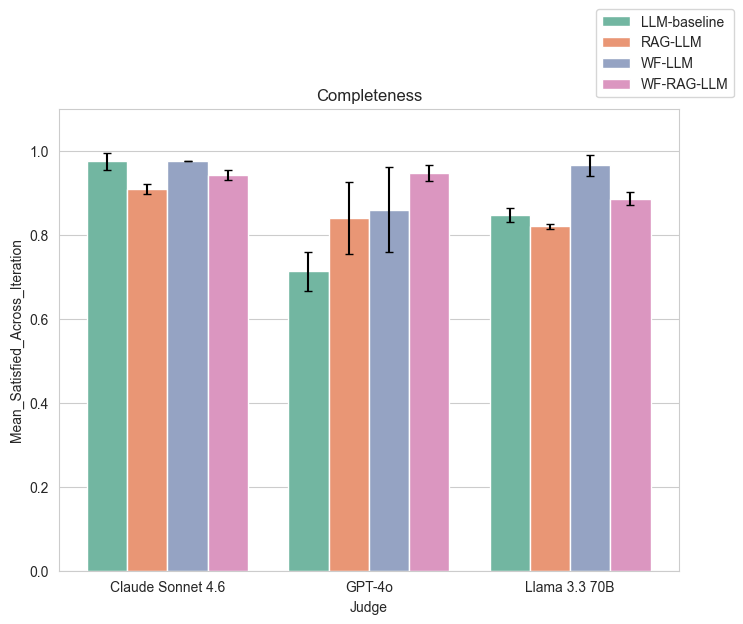

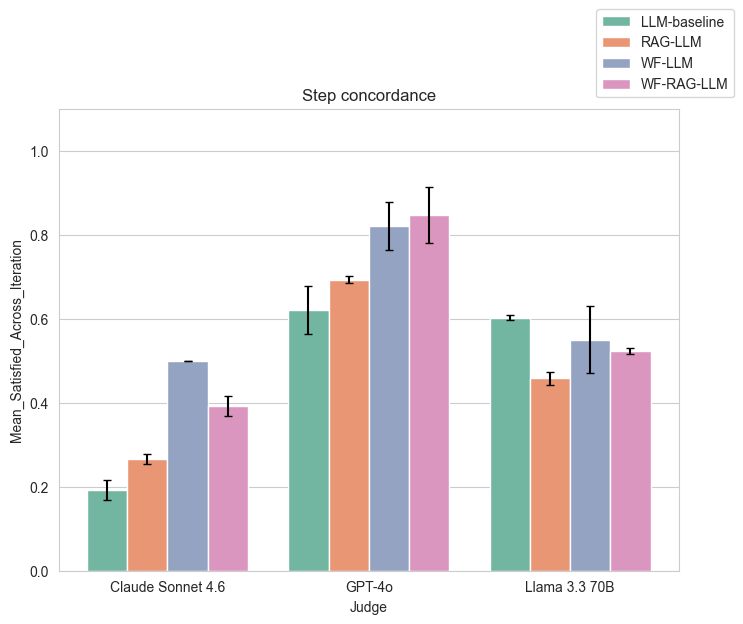

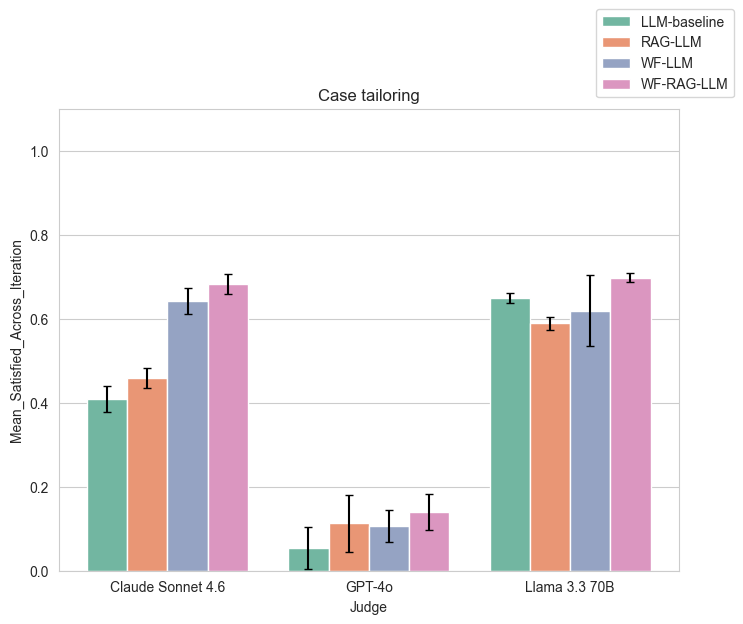

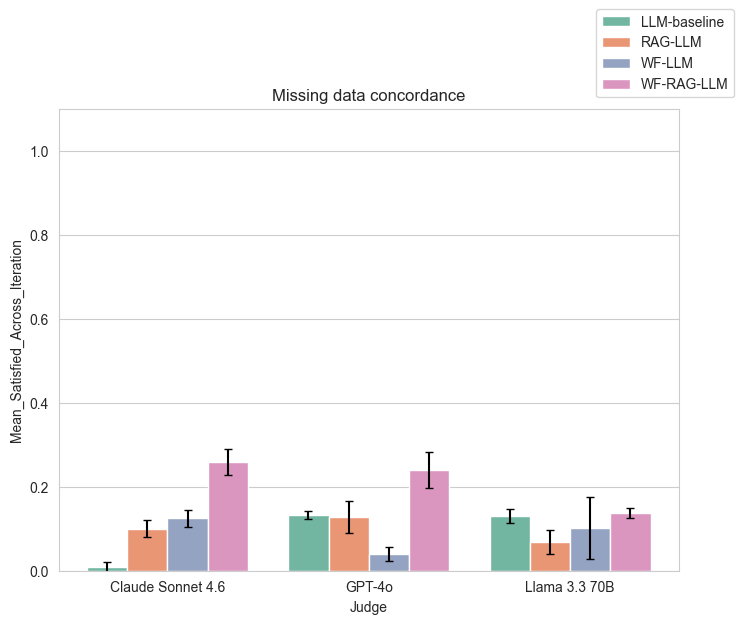

In [24]:
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for c in criteria:
    data_plot = summary_eval_tb_for_graph.loc[summary_eval_tb_for_graph["Criterion"]==c]
    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Judge", y="Mean_Satisfied_Across_Iteration", hue="Approach", errorbar=None)

    x_positions = {
        cat: i for i, cat in enumerate(data_plot["Judge"].unique())
    }

    n_hue = data_plot["Approach"].nunique()
    width = 0.8 / n_hue

    for i, (_, row) in enumerate(data_plot.iterrows()):
        x = x_positions[row["Judge"]]
        
        hue_index = list(data_plot["Approach"].unique()).index(row["Approach"])
        offset = -0.4 + width/2 + hue_index * width
        
        ax.errorbar(
            x=x + offset,
            y=row["Mean_Satisfied_Across_Iteration"],
            yerr=row["STD_Satisfied_Across_Iteration"],
            fmt="none",
            color="black",
            capsize=3
        )
    plt.title(c.replace("_"," "))
    plt.ylim([0,1.1])
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.23))
    # ax.set_xticklabels(list(approaches_names_map.values()))
    plt.show()
    fig.savefig(f"results/{version}_{iteration}/LLM_as_jury_{c}_{n_case_eval}_cases.png", dpi=600, format="png", bbox_inches='tight')
    

In [25]:
final_table = pd.DataFrame(columns=["Criterion","Approach","Jury_Mean_Satisfied"])
for c in criteria:
    for a in approaches:
        jury_values = summary_eval_tb_for_graph.loc[(summary_eval_tb_for_graph["Approach"]==approaches_names_map[a]) & (summary_eval_tb_for_graph["Criterion"]==c),"Mean_Satisfied_Across_Iteration"].values
        print(f"Approach: {a}; Criterion: {c} --> len: {len(jury_values)}")
        jury_mean = round(np.mean(jury_values),3)
        final_table.loc[len(final_table)] = [c, approaches_names_map[a], jury_mean]


Approach: Model_Alone; Criterion: Completeness --> len: 3
Approach: Model_Studies; Criterion: Completeness --> len: 3
Approach: Model_Workflow; Criterion: Completeness --> len: 3
Approach: Model_Workflow_Studies; Criterion: Completeness --> len: 3
Approach: Model_Alone; Criterion: Step_concordance --> len: 3
Approach: Model_Studies; Criterion: Step_concordance --> len: 3
Approach: Model_Workflow; Criterion: Step_concordance --> len: 3
Approach: Model_Workflow_Studies; Criterion: Step_concordance --> len: 3
Approach: Model_Alone; Criterion: Case_tailoring --> len: 3
Approach: Model_Studies; Criterion: Case_tailoring --> len: 3
Approach: Model_Workflow; Criterion: Case_tailoring --> len: 3
Approach: Model_Workflow_Studies; Criterion: Case_tailoring --> len: 3
Approach: Model_Alone; Criterion: Missing_data_concordance --> len: 3
Approach: Model_Studies; Criterion: Missing_data_concordance --> len: 3
Approach: Model_Workflow; Criterion: Missing_data_concordance --> len: 3
Approach: Model_W

In [11]:
final_table

,Criterion,Approach,Jury_Mean_Satisfied
0,Completeness,LLM-baseline,0.836
1,Completeness,RAG-LLM,0.847
2,Completeness,WF-LLM,0.934
3,Completeness,WF-RAG-LLM,0.917
4,Step_concordance,LLM-baseline,0.516
5,Step_concordance,RAG-LLM,0.539
6,Step_concordance,WF-LLM,0.614
7,Step_concordance,WF-RAG-LLM,0.583
8,Case_tailoring,LLM-baseline,0.303
9,Case_tailoring,RAG-LLM,0.403


In [26]:
final_table.to_csv(f"results/{version}_{iteration}/mean_eval_jury_{n_case_eval}_cases.csv",index=False)

### Intra-judge reliability

In [27]:
eval_final_data_normalized = pd.read_csv(f"results/{version}_{iteration}/LLM_as_jury_complete_results_normalized_{n_case_eval}_cases.csv")

In [31]:
eval_final_data_normalized.head()

,Approach,Judge,Iteration,Criterion,Normalized_Mean_Satisfied
0,Model_Alone,claude,0,Completeness,0.978
1,Model_Alone,claude,0,Step_concordance,0.222
2,Model_Alone,claude,0,Case_tailoring,0.333
3,Model_Alone,claude,0,Missing_data_concordance,0.000
4,Model_Studies,claude,0,Completeness,0.889


In [28]:
def compute_icc(df_wide: pd.DataFrame) -> float:
    """
    Compute ICC(3,1) for intra-judge reliability.

    Parameters
    ----------
    df_wide : pd.DataFrame
        Long-format dataframe with columns:
        - 'target'  : approach (Model_Alone, Model_Studies, ...)
        - 'rater'   : evaluation repetition (0, 1, 2)
        - 'score'   : Normalized_Mean_Satisfied

    Returns
    -------
    float
        ICC(3,1) estimate and 95% CI
    """
    icc_results = pg.intraclass_corr(
        data=df_wide,
        targets='Approach',
        raters='Iteration',
        ratings='Normalized_Mean_Satisfied'
    )
    # print(icc_results)
    row = icc_results[icc_results['Type'] == 'ICC(C,1)']
    return {
        'icc': row['ICC'].values[0],
        'ci95_low': row['CI95'].values[0][0],
        'ci95_high': row['CI95'].values[0][1]
    }

In [29]:
icc_tb = pd.DataFrame(columns=["Judge", "Criterion", "Mean STD Across Approaches","ICC(3,1)"])
for judge in model_brief_names:
    for c in criteria:
        judge_data = eval_final_data_normalized.loc[(eval_final_data_normalized["Judge"]==judge) & (eval_final_data_normalized["Criterion"]==c),:]
        # print(f"Judge {judge}; Criterion: {c} --> {len(judge_data)}")
        icc_dict = compute_icc(judge_data)
        # print(f"Judge {judge}; Criterion: {c} --> {icc_dict}")
        icc_ci = [round(max([icc_dict["ci95_low"], 0]),3), round(icc_dict["ci95_high"],3)]

        # Mean std across approaches 
        std_iteration = []
        for it in [0,1,2]:
            judge_data_it = judge_data.loc[judge_data["Iteration"]==it]
            std_approaches = np.std(judge_data_it['Normalized_Mean_Satisfied'].to_list())
            std_iteration.append(std_approaches)
        
        icc_tb.loc[len(icc_tb)] = [judge, c, round(np.mean(std_iteration),3), f"{round(icc_dict["icc"],3)} ({icc_ci[0]}-{icc_ci[1]})"]

In [30]:
icc_tb.to_csv(f"results/{version}_{iteration}/LLM_ICC_{n_case_eval}_cases.csv", index=False)

### Aggregate judges final score

In [5]:
# Runs 
iteration = [0,1,2]
version = "v5_iteration"
dir_path = [f"results/{version}_{i}" for i in iteration]
final_aggregated_score = pd.DataFrame(columns=criteria, index=approaches_names_map.values())
for a in approaches_names_map.values():
    for c in criteria:
        s_list = []
        for d in dir_path:
            final_score = pd.read_csv(f"{d}/mean_eval_jury_100_cases.csv")
            s = final_score.loc[(final_score["Approach"]==a) & (final_score["Criterion"]==c),"Jury_Mean_Satisfied"].item()
            s_list.append(s)
        final_aggregated_score.loc[a, c] = s_list

In [16]:
final_aggregated_score

,Completeness,Step_concordance,Case_tailoring,Missing_data_concordance
LLM-baseline,"[0.79, 0.836, 0.845]","[0.411, 0.516, 0.471]","[0.318, 0.303, 0.37]","[0.045, 0.069, 0.09]"
RAG-LLM,"[0.847, 0.847, 0.856]","[0.478, 0.539, 0.473]","[0.413, 0.403, 0.387]","[0.128, 0.049, 0.098]"
WF-LLM,"[0.964, 0.934, 0.933]","[0.69, 0.614, 0.623]","[0.521, 0.531, 0.456]","[0.192, 0.115, 0.089]"
WF-RAG-LLM,"[0.947, 0.917, 0.925]","[0.602, 0.583, 0.587]","[0.519, 0.487, 0.507]","[0.225, 0.156, 0.212]"


In [17]:
final_aggregated_score.to_csv("results/final_aggregated_results_v5.csv")

### Step 1: Resectability Label Comparison

In [31]:
# Read the resectability labels extracted from Step1
data_dir = "../data/"
res_dir = "results/"
strategy = "OneText"
version = "v5"
iteration = "iteration_2"

n_case_eval = 100

step1_label_data = pd.read_csv(f"{data_dir}{version}/resectability_label_{version}_{iteration}.csv")

In [32]:
labels=["upfront resectable", "potentially resectable", "not resectable"]

In [33]:
labels_approach = {a:[] for a in approaches} 
for a in approaches:
    model_labels = step1_label_data.loc[step1_label_data["Approach"]==a, "Resectability_Label"].to_list()
    if len(model_labels) != n_case_eval:
        print(f"Warning with approach {a}; {len(model_labels)}")
    else:
        labels_approach[a] = model_labels

In [34]:
expert_labels = step1_label_data.loc[step1_label_data["Approach"]=="Expert", "Resectability_Label"].to_list()
print(len(expert_labels))

100


In [35]:
# Accuracy table
acc_tb = pd.DataFrame(columns=["Accuracy"], index=approaches)
for a in labels_approach.keys():
    true_s = 0
    for i in range(0, len(expert_labels)):
        if labels_approach[a][i] == expert_labels[i]:
            true_s += 1
    acc = round(true_s/len(expert_labels),3)
    acc_tb.loc[a, "Accuracy"] = acc

acc_tb.to_csv(f"{res_dir}{version}_{iteration}/resectability_accuracy.csv")
        

In [36]:
# Per-label Accuracy table
acc_tb = pd.DataFrame(columns=[f"Count_{l}" for l in labels]+[f"Accuracy_{l}" for l in labels], index=approaches)
for a in labels_approach.keys():
    #print(f"Approach: {a}")
    true_s = {l:0 for l in labels}
    for i in range(0, len(expert_labels)):
        if labels_approach[a][i] == expert_labels[i]:
            true_s[expert_labels[i]] += 1
    for l in labels:
        #print(f"Label: {l}; {true_s[l]}/{len([t for t in expert_labels if t == l])}")
        acc = round(true_s[l]/len([t for t in expert_labels if t == l]),3)
        acc_tb.loc[a, f"Count_{l}"] = len([t for t in expert_labels if t == l])
        acc_tb.loc[a, f"Accuracy_{l}"] = acc

acc_tb.to_csv(f"{res_dir}{version}_{iteration}/resectability_accuracy_per_label.csv")

In [37]:
weighted_acc = pd.DataFrame(columns=["Weighted_Acc"], index=approaches)

for a in approaches:
    wa = 0
    for rc in labels:
        wa += (acc_tb.loc[a, f"Count_{rc}"]/100) * acc_tb.loc[a, f"Accuracy_{rc}"]
        weighted_acc.loc[a, "Weighted_Acc"] = wa


In [38]:
weighted_acc

,Weighted_Acc
Model_Alone,0.65023
Model_Studies,0.65985
Model_Workflow,0.75976
Model_Workflow_Studies,0.74988


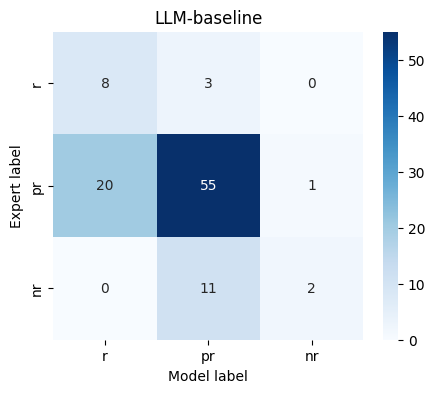

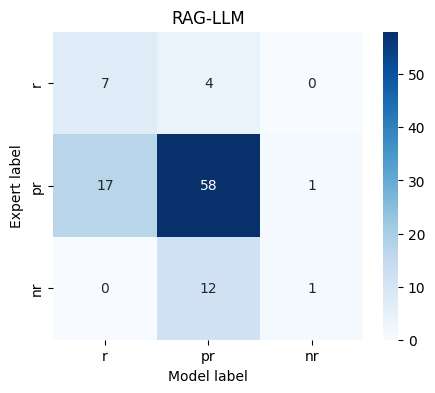

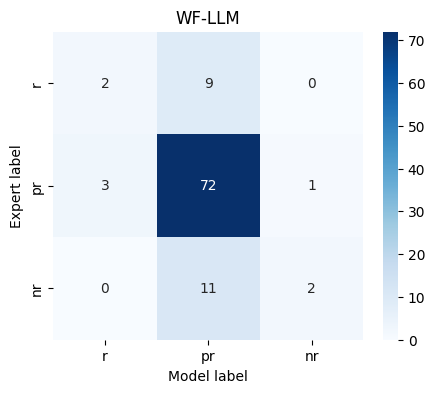

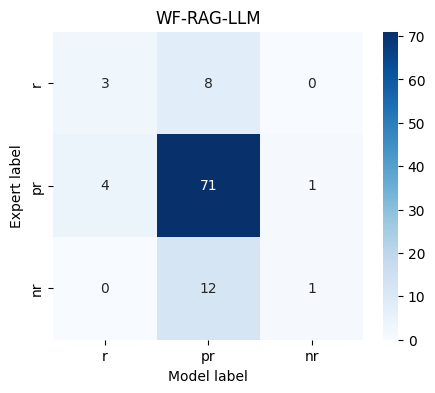

In [39]:
categories = ["r", "pr", "nr"]
for a in labels_approach.keys():
    cm = confusion_matrix(expert_labels, labels_approach[a], labels=labels)
    fig = plt.figure(figsize=(5,4))
    sns.heatmap(cm, cmap="Blues", annot=True, xticklabels=categories, yticklabels=categories)
    plt.ylabel('Expert label')
    plt.xlabel('Model label')
    plt.title(approaches_names_map[a])
    fig.savefig(f"{res_dir}{version}_{iteration}/resectability_confusion_matrix/{a}_update.png", dpi=600, format="png", bbox_inches='tight')
    

### Aggregated classification

In [14]:
iteration = [0,1,2]
version = "v5"
labels=["upfront resectable", "potentially resectable", "not resectable"]
dir_path = [f"results/{version}_iteration_{i}" for i in iteration]
r_cols = [f"Accuracy_{l}" for l in labels]

resectability_aggregated = pd.DataFrame(columns=["Overall"] + r_cols, index=approaches)
for a in approaches:
        agg_class_overall = []
        for d in dir_path:
            df1 = pd.read_csv(f"{d}/resectability_accuracy.csv",index_col=0)
            agg_class_overall.append(df1.loc[a, "Accuracy"].item())
        resectability_aggregated.loc[a, "Overall"] = agg_class_overall

        for c in r_cols:
            agg_class = []
            for d in dir_path:
                df2 = pd.read_csv(f"{d}/resectability_accuracy_per_label.csv",index_col=0)
                agg_class.append(df2.loc[a, c].item())
            resectability_aggregated.loc[a, c] = agg_class

In [15]:
resectability_aggregated

,Overall,Accuracy_upfront resectable,Accuracy_potentially resectable,Accuracy_not resectable
Model_Alone,"[0.61, 0.65, 0.65]","[0.818, 0.727, 0.727]","[0.671, 0.724, 0.724]","[0.077, 0.154, 0.154]"
Model_Studies,"[0.64, 0.67, 0.66]","[0.545, 0.636, 0.636]","[0.75, 0.776, 0.763]","[0.077, 0.077, 0.077]"
Model_Workflow,"[0.77, 0.77, 0.76]","[0.273, 0.273, 0.182]","[0.961, 0.961, 0.947]","[0.077, 0.077, 0.154]"
Model_Workflow_Studies,"[0.74, 0.75, 0.75]","[0.091, 0.273, 0.273]","[0.947, 0.934, 0.934]","[0.077, 0.077, 0.077]"


In [16]:
resectability_aggregated.to_csv("results/resectability_label_aggregated_v5.csv")

### NER Analysis Results

In [12]:
metrics = {"order": ["LCS", "One_Hot_Encoding_DTW"], "semantic": ["TSR", "Levenshtein", "Exact_Match_P"]}
data_dir = "results_ner/"
version = "v2"
res_dir = f"results/{version}/"

In [6]:
# Check the number of cases for each metric results 
semantic_data = {m:{s: {a: {} for a in approaches} for s in ["Step2", "Step3"]} for m in metrics["semantic"]}
order_data = {m: {a: {} for a in approaches} for m in metrics["order"]}

for tp in metrics.keys():
    if tp == "order":
        f_name_begin = f"NER_{tp}_metric_Step2_"
        for m in metrics[tp]:
            for a in approaches:
                data = pd.read_csv(f"{data_dir}{f_name_begin}{a}.csv")
                if len(data) != n_case_eval:
                    print(f"Warning <data_len> for {tp} data, Approach {a}")
                else:
                    order_data[m][a] = data.loc[:,m]
    else:
        for s in ["Step2", "Step3"]:
            f_name_begin = f"NER_{tp}_metric_{s}_"
            for m in metrics[tp]:
                for a in approaches:
                    data_dict = {}
                    data = pd.read_csv(f"{data_dir}{f_name_begin}{a}.csv")
                    data_m = data.loc[data["Metric"]==m]
                    entity = set(data_m["Label"])
                    if s == "Step2":
                        external_entity = [e for e in entity if e not in step2_labels]
                    else:
                        external_entity = [e for e in entity if e not in step3_labels]
                    if len(external_entity) == 0:
                        for e in entity:
                            data_m_e = data_m.loc[data_m["Label"]==e]
                            if len(data_m_e) != n_case_eval:
                                print(f"Warning <data_len> for {m} data, Approach: {a}, Entity: {e}")
                            else:
                                data_dict[e] = data_m_e
                    else:
                        print(f"Warning <external_entities> for {m} data, Approach: {a}, Entity: {e}")
                    semantic_data[m][s].update({a:data_dict})


In [7]:
print("Order Data")
for m in order_data.keys():
    for a in order_data[m].keys():
        print(f"Metric {m}, Approach {a} --> {len(order_data[m][a])}")

print("Semantic Data")
for m in semantic_data.keys():
    for s in semantic_data[m].keys():
        for a in semantic_data[m][s].keys():
            for e in semantic_data[m][s][a].keys():
                print(f"Metric {m}, Step {s}, Approach {a}, Label: {e} --> {len(semantic_data[m][s][a][e])}")

Order Data
Metric LCS, Approach Model_Alone --> 100
Metric LCS, Approach Model_Studies --> 100
Metric LCS, Approach Model_Workflow --> 100
Metric LCS, Approach Model_Workflow_Studies --> 100
Metric One_Hot_Encoding_DTW, Approach Model_Alone --> 100
Metric One_Hot_Encoding_DTW, Approach Model_Studies --> 100
Metric One_Hot_Encoding_DTW, Approach Model_Workflow --> 100
Metric One_Hot_Encoding_DTW, Approach Model_Workflow_Studies --> 100
Semantic Data
Metric TSR, Step Step2, Approach Model_Alone, Label: Imaging_Test --> 100
Metric TSR, Step Step2, Approach Model_Alone, Label: Therapy --> 100
Metric TSR, Step Step2, Approach Model_Alone, Label: Cancer_Surgery --> 100
Metric TSR, Step Step2, Approach Model_Studies, Label: Imaging_Test --> 100
Metric TSR, Step Step2, Approach Model_Studies, Label: Therapy --> 100
Metric TSR, Step Step2, Approach Model_Studies, Label: Cancer_Surgery --> 100
Metric TSR, Step Step2, Approach Model_Workflow, Label: Imaging_Test --> 100
Metric TSR, Step Step2, Ap

In [16]:
# Compute statistics of each metric across cases 
def statistics(list_score: list):
    statistics = {}
    statistics["Mean"] = round(np.nanmean(list_score), 2)
    statistics["STD"] = round(np.nanstd(list_score), 2)
    statistics["Median"] = round(np.nanmedian(list_score), 2)
    statistics["Percentiles_25-75"] = [round(np.nanpercentile(list_score, 25), 2), round(np.nanpercentile(list_score, 75), 2)]
    return statistics


# order metrics
order_stats = pd.DataFrame(columns=["Approach", "Metric","Mean", "STD", "Median", "Percentiles_25-75"])
for m in order_data.keys():
    for a in approaches:
        values_ = order_data[m][a].to_list()
        stats = statistics(values_)
        order_stats.loc[len(order_stats)] = [a, m] + list(stats.values())

# Semantic metrics 
# Set labels
labels = ["Imaging_Test", "Cancer_Surgery", "Therapy"]
sem_stats_step2 = pd.DataFrame(columns=["Approach", "Label", "Metric", "Mean", "STD", "Median", "Percentiles_25-75"])
sem_stats_step3 = pd.DataFrame(columns=["Approach", "Label", "Metric", "Mean", "STD", "Median", "Percentiles_25-75"])
for m in metrics["semantic"]:
    for s in semantic_data[m].keys():
        for a in semantic_data[m][s].keys():
            # for e in semantic_data[m][s][a].keys():
            # Consider only a subset of labels 
            for e in labels:
                stats = statistics(semantic_data[m][s][a][e]["Value"].to_list())
                if s == "Step2":
                    # print(f"Update df fro {s} with {m}, {e}, {a}")
                    sem_stats_step2.loc[len(sem_stats_step2)] = [a, e, m] + list(stats.values())
                else:
                    # print(f"Update df fro {s} with {m}, {e}, {a}")
                    sem_stats_step3.loc[len(sem_stats_step3)] = [a, e, m] + list(stats.values())

In [17]:
order_stats.to_csv(f"{res_dir}order_stats.csv")

In [ ]:
# sem_stats_step2.to_csv(f"results/semantic_stats_step2.csv", index=False)
sem_stats_step3.to_csv(f"{res_dir}semantic_stats_step3_three_labels.csv", index=False)

In [21]:
# Summary table: stats across labels
summary_tb = pd.DataFrame(columns=["Approach", "Step", "Metric", "Mean_Across_Label", "STD_Across_Label"])
for m in metrics["semantic"]:
    for a in approaches:
        print("Step2")
        data_m_a = sem_stats_step2.loc[(sem_stats_step2["Metric"]==m) & (sem_stats_step2["Approach"]==a), "Mean"].to_list()
        if len(data_m_a) != len(step2_labels):
            print(f"Warnings with metric {m}, Approach {a}")
        else:
            stats = [round(np.mean(data_m_a),2), round(np.std(data_m_a),2)]
            summary_tb.loc[len(summary_tb)] = [a, "Step2", m] + stats

        print("Step3")
        data_m_a = sem_stats_step3.loc[(sem_stats_step3["Metric"]==m) & (sem_stats_step3["Approach"]==a), "Mean"].to_list()
        if len(data_m_a) != len(step2_labels):
            print(f"Warnings with metric {m}, Approach {a}")
        else:
            stats = [round(np.mean(data_m_a),2), round(np.std(data_m_a),2)]
            summary_tb.loc[len(summary_tb)] = [a, "Step3", m] + stats


Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3
Step2
Step3


In [ ]:
summary_tb.to_csv(f"{res_dir}summary_stats_ner_three_labels.csv", index=False)

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\3492070194.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


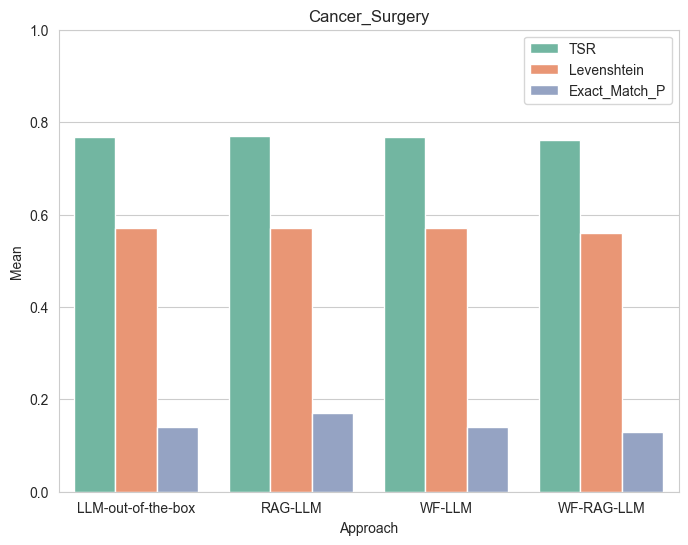

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\3492070194.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


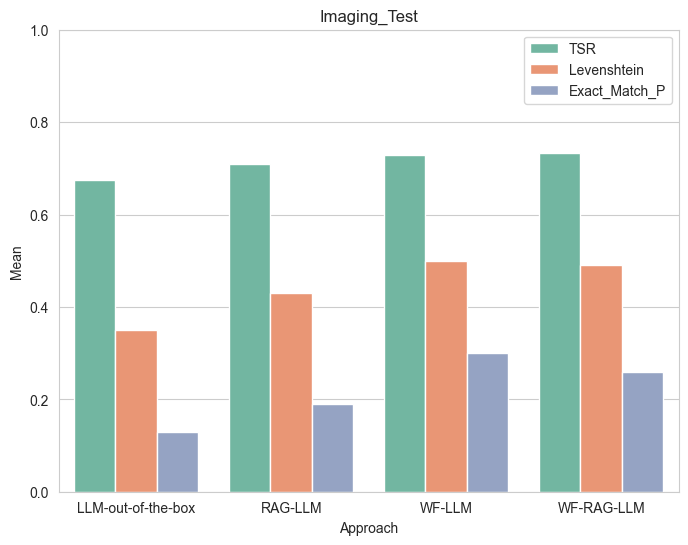

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\3492070194.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


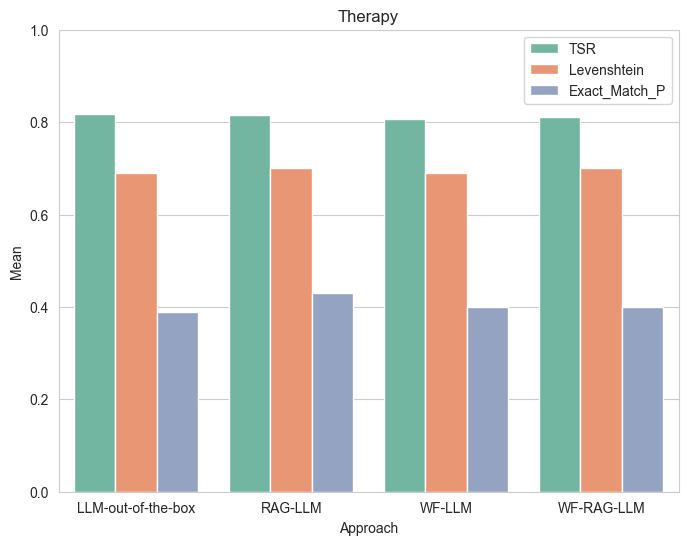

In [ ]:
# Images for Step 2
# Bring TSR to the same scale 
sem_data = sem_stats_step2.copy()
sem_data.loc[sem_data["Metric"]=="TSR", "Mean"] = sem_data.loc[sem_data["Metric"]=="TSR", "Mean"]/100
# print(sem_data.loc[sem_stats_step2["Metric"]=="TSR"][1:3])

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for l in step2_labels:
    data_plot = sem_data.loc[sem_data["Label"]==l]

    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Approach", y="Mean", hue="Metric",)
    plt.title(l)
    plt.ylim([0,1])
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
    ax.set_xticklabels(list(approaches_names_map.values()))
    plt.show()
    fig.savefig(f"results/Step12_{l}.png", dpi=600, format="png", bbox_inches='tight')
    
    


C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\114767106.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


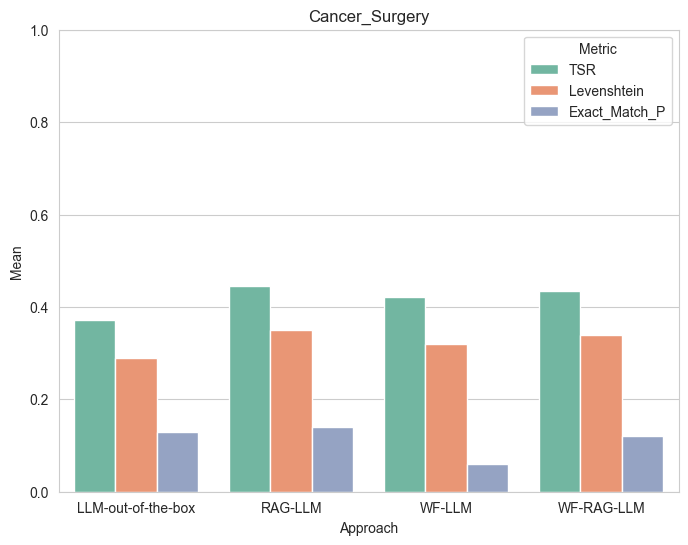

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\114767106.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


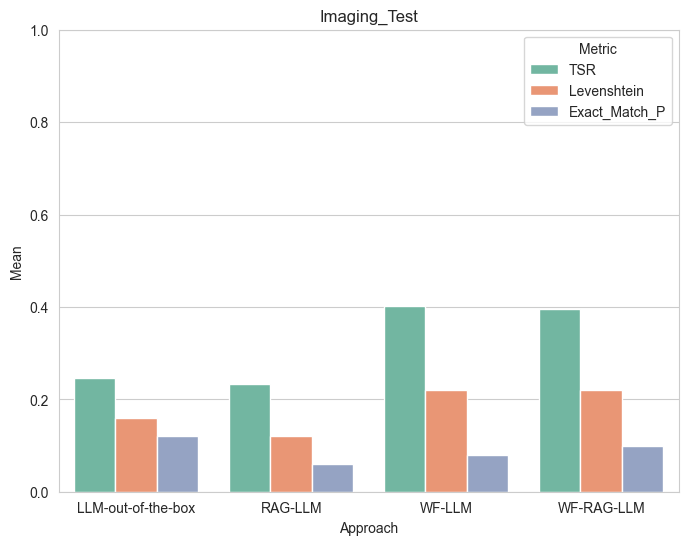

C:\Users\fr2332\AppData\Local\Temp\ipykernel_17768\114767106.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()))


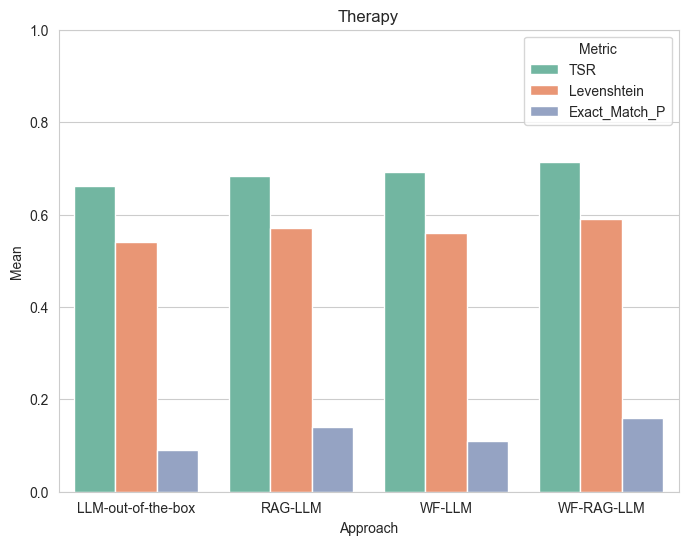

In [ ]:
# Images for Step 3
# Bring TSR to the same scale 
sem_data = sem_stats_step3.copy()
sem_data.loc[sem_data["Metric"]=="TSR", "Mean"] = sem_data.loc[sem_data["Metric"]=="TSR", "Mean"]/100
# print(sem_data.loc[sem_stats_step12["Metric"]=="TSR"][1:3])

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for l in step2_labels:
    data_plot = sem_data.loc[sem_data["Label"]==l]

    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Approach", y="Mean", hue="Metric")
    plt.title(l)
    plt.ylim([0,1])
    ax.set_xticklabels(list(approaches_names_map.values()))
    plt.show()
    fig.savefig(f"results/Step3_{l}{a}.png", dpi=600, format="png", bbox_inches='tight')

C:\Users\fr2332\AppData\Local\Temp\ipykernel_5848\853771757.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()), rotation=45, ha='right')


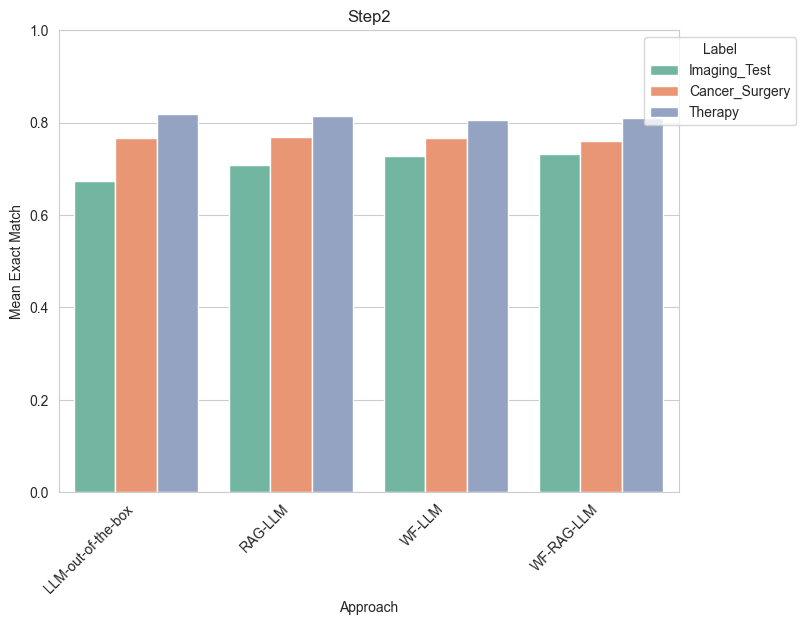

C:\Users\fr2332\AppData\Local\Temp\ipykernel_5848\853771757.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(approaches_names_map.values()), rotation=45, ha='right')


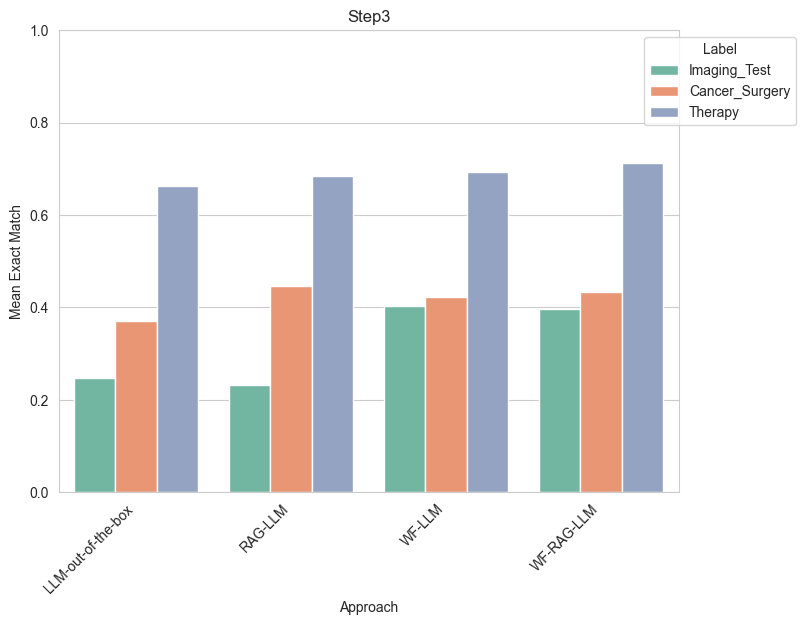

In [41]:

# Images for Step 2 & 3
# Bring TSR to the same scale 
sem_data_2 = sem_stats_step2.copy()
sem_data_2.loc[sem_data_2["Metric"]=="TSR", "Mean"] = sem_data_2.loc[sem_data_2["Metric"]=="TSR", "Mean"]/100
sem_data_3 = sem_stats_step3.copy()
sem_data_3.loc[sem_data_3["Metric"]=="TSR", "Mean"] = sem_data_3.loc[sem_data_3["Metric"]=="TSR", "Mean"]/100
# print(sem_data.loc[sem_stats_step2["Metric"]=="TSR"][1:3])

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

data_plot_2 = sem_data_2.loc[sem_data_2["Metric"]=="TSR"]
data_plot_3 = sem_data_3.loc[sem_data_3["Metric"]=="TSR"]
data_plot = [data_plot_2, data_plot_3]

'''
for d, s in zip(data_plot, ["Step2", "Step3"]):
    bottoms = np.zeros(len(approaches))
    fig, ax = plt.subplots(figsize=(8, 6))
    for l in step2_labels:
        data_plot_l = d.loc[d["Label"]==l]
        ax.bar(data_plot_l["Approach"], data_plot_l["Mean"], label=l, bottom=bottoms)
        bottoms += data_plot_l["Mean"].values

    ax.set_ylim([0,1])
    ax.set_xticklabels(list(approaches_names_map.values()), rotation=45, ha='right')
    ax.set_xlabel('Approach')
    ax.set_ylabel('Mean Exact Match')
    ax.set_title(s)
    ax.legend(title='Label', loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.show()

    fig.savefig(f"{res_dir}NER_images/{s}_EM.png", dpi=600, format="png", bbox_inches='tight')
'''

for d, s in zip(data_plot, ["Step2", "Step3"]):
    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(d, x="Approach", y="Mean", hue="Label")

    ax.set_ylim([0,1])
    ax.set_xticklabels(list(approaches_names_map.values()), rotation=45, ha='right')
    ax.set_xlabel('Approach')
    ax.set_ylabel('Mean Exact Match')
    ax.set_title(s)
    ax.legend(title='Label', loc='upper right', bbox_to_anchor=(1.20, 1))

    plt.show()

    fig.savefig(f"{res_dir}NER_images/{s}_TSR.png", dpi=600, format="png", bbox_inches='tight')

### Taxonomy-based analysis

In [29]:
# Read data: mean TRS and exact match across the labels for each domain
data_dir = "results_taxonomy/"
semantic_data_dict = {a:None for a in approaches}
for a in approaches:
    semantic_data = pd.read_csv(f"{data_dir}mean_semantic_metric_across_entities_{a}_excluding.csv")
    unique_patient = set(semantic_data["Case_N"])
    unique_domain = set(semantic_data["Domain"])
    semantic_data_dict[a] = semantic_data
    print(f"Approach: {a}; Unique patient: {len(unique_patient)}; Unique domain: {len(unique_domain)}")

Approach: Model_Alone; Unique patient: 44; Unique domain: 7
Approach: Model_Studies; Unique patient: 44; Unique domain: 7
Approach: Model_Workflow; Unique patient: 44; Unique domain: 7
Approach: Model_Workflow_Studies; Unique patient: 44; Unique domain: 7


In [30]:
semantic_data_dict["Model_Alone"].columns

Index(['Case_N', 'Domain', 'Metric', 'Mean', 'STD'], dtype='str')

In [31]:
for m in ["TSR", "Exact_Match_P"]:
    print("Metric ", m)
    final_semantic_res = pd.DataFrame(columns=list(unique_domain),index=approaches)
    for a in approaches:
        for d in unique_domain:
            metric_domain_data = semantic_data_dict[a].loc[(semantic_data_dict[a]["Metric"]==m) & (semantic_data_dict[a]["Domain"]==d),"Mean"].values
            print(f"Approach {a}; Domain {d} --> len: {len(metric_domain_data)}")
            final_semantic_res.loc[a, d] = f"{round(np.mean(metric_domain_data),3)} ({round(np.std(metric_domain_data),3)})"

Metric  TSR
Approach Model_Alone; Domain surgical_planning --> len: 44
Approach Model_Alone; Domain primary_tumor_status --> len: 44
Approach Model_Alone; Domain liver_metastases --> len: 44
Approach Model_Alone; Domain imaging --> len: 44
Approach Model_Alone; Domain extrahepatic_disease --> len: 44
Approach Model_Alone; Domain systemic_therapy --> len: 44
Approach Model_Alone; Domain tumor_biology --> len: 44
Approach Model_Studies; Domain surgical_planning --> len: 44
Approach Model_Studies; Domain primary_tumor_status --> len: 44
Approach Model_Studies; Domain liver_metastases --> len: 44
Approach Model_Studies; Domain imaging --> len: 44
Approach Model_Studies; Domain extrahepatic_disease --> len: 44
Approach Model_Studies; Domain systemic_therapy --> len: 44
Approach Model_Studies; Domain tumor_biology --> len: 44
Approach Model_Workflow; Domain surgical_planning --> len: 44
Approach Model_Workflow; Domain primary_tumor_status --> len: 44
Approach Model_Workflow; Domain liver_met

In [32]:
final_semantic_res

,surgical_planning,primary_tumor_status,liver_metastases,imaging,extrahepatic_disease,systemic_therapy,tumor_biology
Model_Alone,nan (nan),nan (nan),0.753 (0.269),nan (nan),nan (nan),nan (nan),nan (nan)
Model_Studies,nan (nan),nan (nan),0.752 (0.243),nan (nan),nan (nan),nan (nan),nan (nan)
Model_Workflow,nan (nan),nan (nan),nan (nan),nan (nan),nan (nan),nan (nan),nan (nan)
Model_Workflow_Studies,nan (nan),nan (nan),nan (nan),nan (nan),nan (nan),nan (nan),nan (nan)
